In [58]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Dataset Loading

In [59]:
# โหลดไฟล์ .npy
images = np.load("../../data/processed_data/char_subject_code_tn/images.npy")
labels = np.load("../../data/processed_data/char_subject_code_tn/labels.npy")

# ตรวจสอบข้อมูล
print(f"Shape of images: {images.shape}")
print(f"Shape of labels: {labels.shape}")


Shape of images: (3663, 32, 32)
Shape of labels: (3663,)


In [60]:
X = images
y = labels

# ดู min max
print("min max:",np.min(X), np.max(X))

# หา missing value
print("missing value:",np.isnan(X).sum())

# คลาส
print("class:", np.unique(y))

min max: 0 255
missing value: 0
class: [ 0  1  2  3  4  5  6  7  8  9 10]


# Visualization

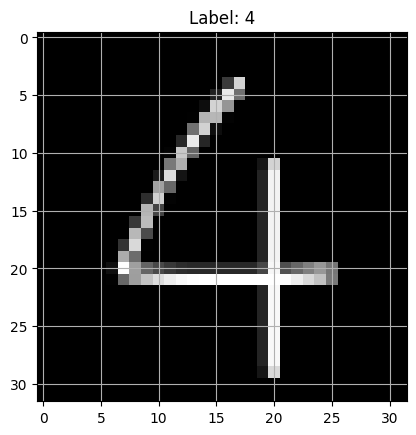

In [24]:
# แสดงภาพเดี่ยว(Single Image)
# แสดงภาพตัวอย่างแรก
plt.imshow(images[0], cmap="gray")
plt.title(f"Label: {labels[0]}")
plt.axis("on")  # ซ่อนแกน
plt.grid()
plt.show()


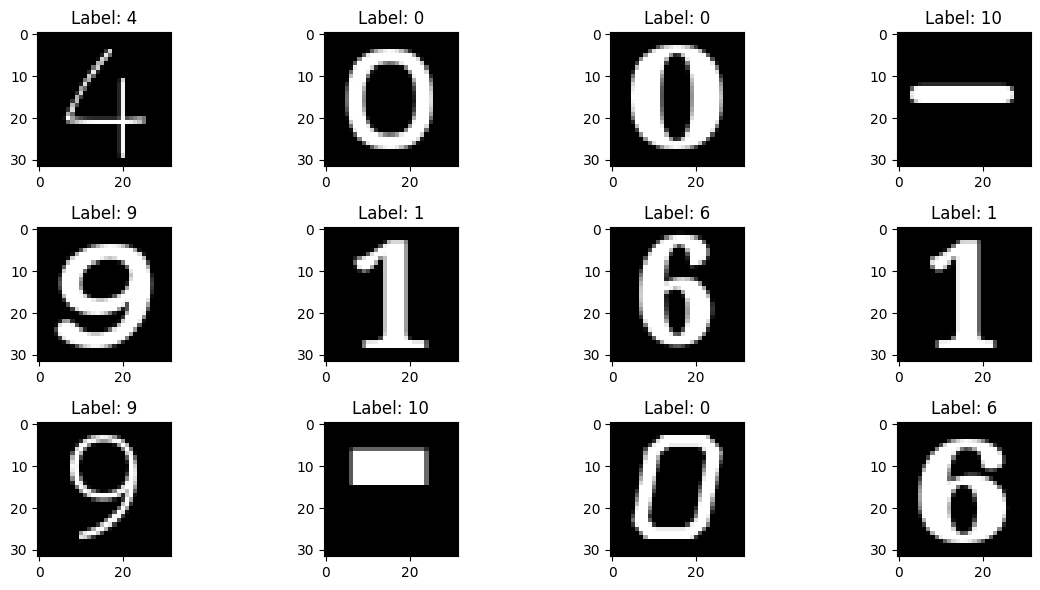

In [25]:
# ตั้งค่าจำนวนภาพที่ต้องการแสดง
num_images = 12  # จำนวนภาพทั้งหมดที่ต้องการแสดง
num_cols = 4     # จำนวนคอลัมน์
num_rows = num_images // num_cols

# สร้างกริดภาพ
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(images[i], cmap="gray")
        ax.set_title(f"Label: {labels[i]}")
        ax.axis("on")

plt.tight_layout()
plt.show()

### ตรวจสอบความสมดุลของคลาส (Class Distribution)

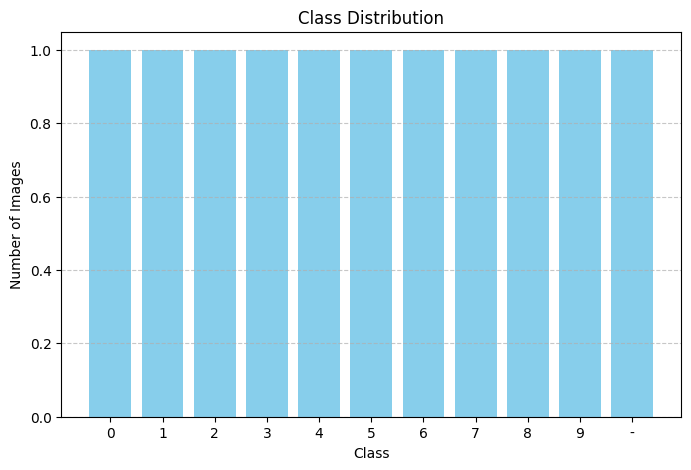

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ตั้งค่า font ให้รองรับภาษาไทย (ตรวจสอบว่า font ดังกล่าวติดตั้งในระบบแล้ว)
plt.rcParams['font.family'] = ['Tahoma']  # หรือใช้ ['Sarabun'] หากมี font นี้
plt.rcParams['axes.unicode_minus'] = False  # แก้ปัญหาเครื่องหมายลบไม่แสดง

from collections import Counter

labels = [
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '-',
]

# นับจำนวนคลาส
class_counts = Counter(labels)

# แสดงกราฟแท่ง (Bar Plot)
plt.figure(figsize=(8, 5))  # ปรับขนาดกราฟ
plt.bar(class_counts.keys(), class_counts.values(), color="skyblue")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

## Train-test Split

In [27]:
from sklearn.model_selection import train_test_split

# 1. แบ่งข้อมูลทั้งหมดออกเป็น Training (70%) กับ Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# 2. จากข้อมูล Temp 30% แบ่งออกเป็น Validation และ Test เท่ากัน (แต่ละ 15% ของข้อมูลทั้งหมด)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ตรวจสอบสัดส่วนข้อมูล
print("Training set:", len(X_train))
print("Validation set:", len(X_val))
print("Test set:", len(X_test))

Training set: 2564
Validation set: 549
Test set: 550


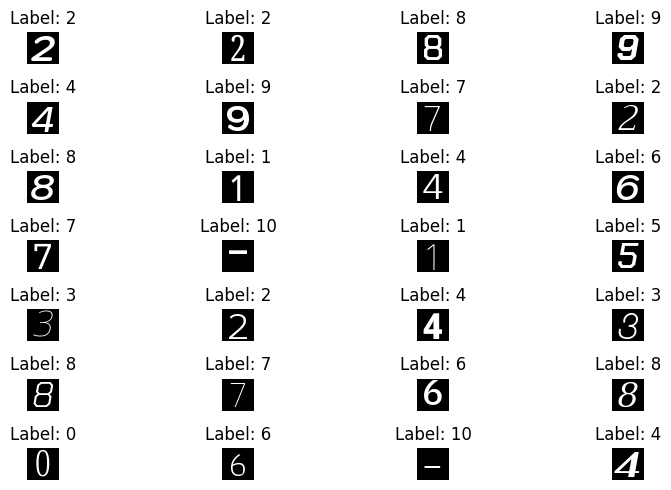

In [28]:
# ตั้งค่าจำนวนภาพที่ต้องการแสดง
num_images = 30  # จำนวนภาพทั้งหมดที่ต้องการแสดง
num_cols = 4     # จำนวนคอลัมน์
num_rows = num_images // num_cols

# สร้างกริดภาพ
fig, axes = plt.subplots(num_rows, num_cols, figsize=(9, 5))

for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(X_train[i], cmap="gray")
        ax.set_title(f"Label: {y_train[i]}")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [1]:
print(X_train.shape)
print(X_test.shape)

NameError: name 'X_train' is not defined

## Prepare Dataset (Re-shape the Structure)

In [30]:
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)
X_val = np.expand_dims(X_val, -1)

In [31]:
# Normalize
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0

In [32]:
# Normalize Check
np.min(X_train), np.max(X_train)

(0.0, 1.0)

In [33]:
# Dimension Check
X_train.shape

(2564, 32, 32, 1)

In [34]:
print('Train: X={}, y={}'.format(X_train.shape, y_train.shape))
print('Test: X={}, y={}'.format(X_test.shape, y_test.shape))

Train: X=(2564, 32, 32, 1), y=(2564,)
Test: X=(550, 32, 32, 1), y=(550,)


# Create Model

In [35]:
num_classes = len(np.unique(y_train))
in_shape = X_train.shape[1:]

print("num classes:",num_classes)
print("input shape:",in_shape)

num classes: 11
input shape: (32, 32, 1)


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# สร้างโมเดล CNN
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=in_shape),  # 32 filters, 3x3 kernel
    MaxPooling2D((2, 2)),  # ลดขนาดภาพลงครึ่งหนึ่ง

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),  # 64 filters
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),  # 128 filters
    MaxPooling2D((2, 2)),

    # Flatten และ Fully Connected Layers
    Flatten(),
    Dense(256, activation='relu'),  # Fully Connected Layer
    Dropout(0.5),  # ลด Overfitting
    Dense(num_classes, activation='softmax')  # Output Layer 
])

# สรุปโครงสร้างโมเดล
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 32, 32, 32)        320       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 16, 16, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 8, 8, 128)         73856     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 4, 4, 128)       

In [37]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [38]:
import time
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# สร้าง object สำหรับ data augmentation ด้วยการกำหนดพารามิเตอร์ที่ต้องการ
datagen = ImageDataGenerator(
    rotation_range=10,         # หมุนภาพสุ่มไม่เกิน 10 องศา
    width_shift_range=0.1,     # เลื่อนภาพในแนวราบไม่เกิน 20%
    height_shift_range=0.1,    # เลื่อนภาพในแนวตั้งไม่เกิน 20%
    shear_range=0.1,           # ปรับมุมของภาพ
    zoom_range=0.1,            # ซูมเข้าออก
    horizontal_flip=False,     # พลิกภาพในแนวนอน (ถ้าจำเป็นให้ตั้งเป็น True)
    fill_mode='nearest'        # วิธีเติมพิกเซลที่หายไปหลังการแปลง
)

start = time.time()
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# เทรนโมเดลโดยใช้ข้อมูลที่ถูกปรับปรุงแบบ Augmentation
datagen.fit(X_train)
history = model.fit(X_train, y_train,
                    batch_size=32,
                    epochs=100,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping],
                    verbose=1)

end = time.time()
print("Time Taken: {:.2f} minutes".format((end - start)/60))

Epoch 1/100
81/81 [==============================] - 1s 9ms/step - loss: 0.8384 - accuracy: 0.7243 - val_loss: 0.0269 - val_accuracy: 0.9982
Epoch 2/100
81/81 [==============================] - 0s 5ms/step - loss: 0.0629 - accuracy: 0.9817 - val_loss: 0.0085 - val_accuracy: 0.9982
Epoch 3/100
81/81 [==============================] - 0s 4ms/step - loss: 0.0303 - accuracy: 0.9871 - val_loss: 0.0119 - val_accuracy: 0.9964
Epoch 4/100
81/81 [==============================] - 0s 5ms/step - loss: 0.0181 - accuracy: 0.9945 - val_loss: 0.0040 - val_accuracy: 0.9982
Epoch 5/100
81/81 [==============================] - 0s 5ms/step - loss: 0.0183 - accuracy: 0.9938 - val_loss: 0.0012 - val_accuracy: 1.0000
Epoch 6/100
81/81 [==============================] - 0s 5ms/step - loss: 0.0117 - accuracy: 0.9969 - val_loss: 0.0075 - val_accuracy: 0.9964
Epoch 7/100
81/81 [==============================] - 0s 5ms/step - loss: 0.0185 - accuracy: 0.9922 - val_loss: 0.0063 - val_accuracy: 0.9982
Epoch 8/100
8

In [50]:
#test_loss, test_acc = model.evaluate(X_test, y_test)
#print(f"Test Accuracy: {test_acc * 100:.2f}%")

score = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {score[0] * 100:.3f}%")
print(f"Test Accuracy: {score[1] * 100:.3f}%")

18/18 [==============================] - 0s 8ms/step - loss: 7.9016e-05 - accuracy: 1.0000
Test Loss: 0.008%
Test Accuracy: 100.000%


### รายละเอียดของกราฟ
Loss:

-Train Loss: แสดงว่าโมเดลเรียนรู้ข้อมูล Training ได้ดีแค่ไหน

-Validation Loss: ช่วยบอกว่าโมเดลเรียนรู้ข้อมูลใหม่ (ที่ไม่เคยเห็นมาก่อน) ได้ดีแค่ไหน

-Validation Loss ที่ลดลงต่อเนื่องแสดงว่าโมเดลยังเรียนรู้ได้ดี แต่ถ้าเพิ่มขึ้นอาจบ่งชี้ว่า Overfitting

Accuracy:

-Train Accuracy: ความแม่นยำของโมเดลบนข้อมูล Training

-Validation Accuracy: ความแม่นยำของโมเดลบนข้อมูล Validation

-ค่า Accuracy ที่ใกล้เคียงกันระหว่าง Train และ Validation หมายถึงโมเดลกำลังเรียนรู้ได้ดี


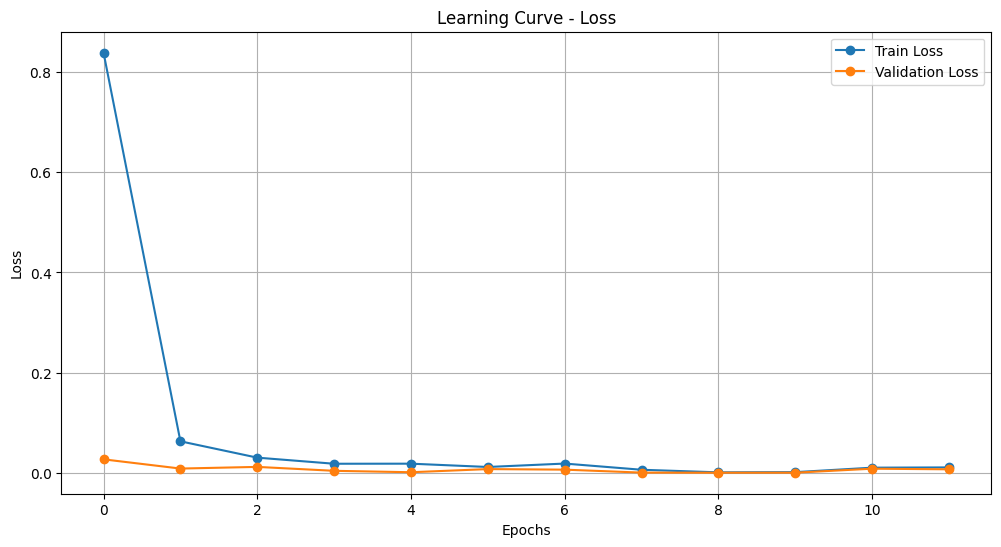

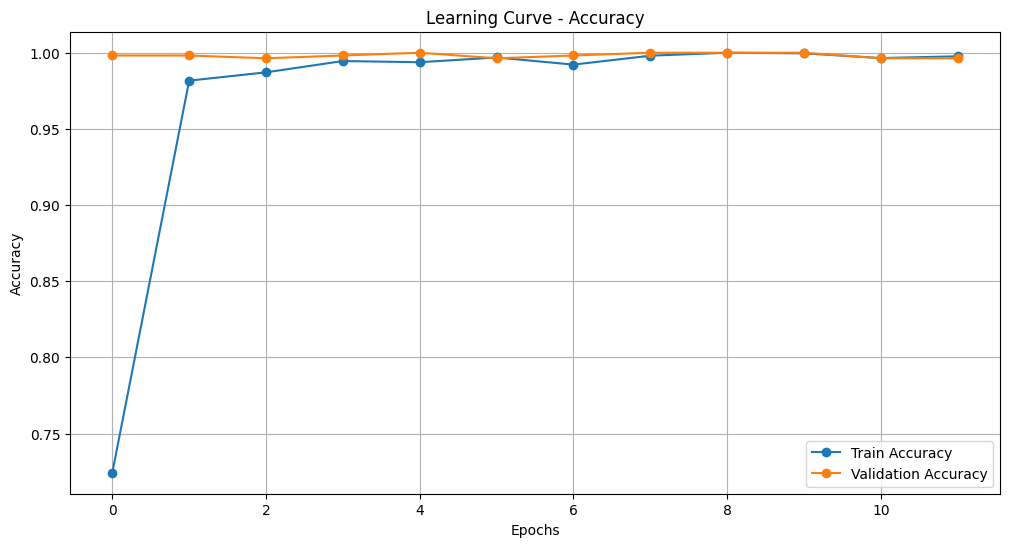

In [43]:
# ดึงข้อมูล Loss และ Accuracy
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# สร้างกราฟ Loss
plt.figure(figsize=(12, 6))
plt.plot(train_loss, label='Train Loss', marker='o')
plt.plot(val_loss, label='Validation Loss', marker='o')
plt.title('Learning Curve - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# สร้างกราฟ Accuracy
plt.figure(figsize=(12, 6))
plt.plot(train_acc, label='Train Accuracy', marker='o')
plt.plot(val_acc, label='Validation Accuracy', marker='o')
plt.title('Learning Curve - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

## Confusion Matrix

18/18 [==============================] - 0s 15ms/step


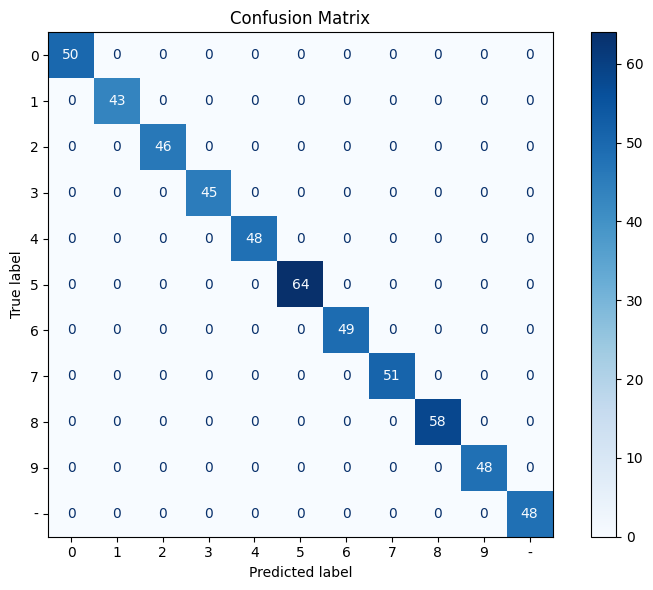

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ตรวจสอบและแปลง y_test ให้เป็น label vector หากอยู่ในรูปแบบ One-Hot
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# ทำนายผลจากโมเดลบนชุดข้อมูล X_test
y_pred = model.predict(X_test)
# แปลงผลการทำนายให้เป็น label โดยใช้ argmax
y_pred_classes = np.argmax(y_pred, axis=1)

# คำนวณ Confusion Matrix จาก y_true และ y_pred_classes
cm = confusion_matrix(y_true, y_pred_classes)

labels_names = [
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '-',
]

# สร้างและปรับขนาดกราฟสำหรับ Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names)
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


# Test Model

### ทำนายภาพเดี่ยว
ใช้ภาพใหม่ (เช่น ภาพที่ไม่ได้อยู่ในชุด Test) เพื่อทดสอบ:

In [25]:
letter_class = [chr(i) for i in range(ord('a'), ord('z') + 1)]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# โหลดภาพใหม่
new_image = cv2.imread("../../data/output_images/output_characters/line_1_char_3.png", cv2.IMREAD_GRAYSCALE)
new_image = cv2.resize(new_image, (64, 64))  # ปรับขนาดให้ตรงกับ Input Shape
#new_image = 255 - new_image # Invert สี
new_image = new_image / 255.0  # Normalization
new_image = np.expand_dims(new_image, axis=(0, -1))  # เพิ่มมิติให้ตรงกับโมเดล

# ทำนายคลาส
prediction = model.predict(new_image)
predicted_class = np.argmax(prediction)

# แสดงผล
plt.imshow(new_image.squeeze(), cmap='gray')
#plt.title(f"Predicted Class: {predicted_class}")
plt.title(f"Predicted Class: {letter_class[predicted_class]}")
plt.axis("on")
plt.show()


### ทดสอบหลายภาพ
ถ้ามีหลายภาพใหม่ในโฟลเดอร์:

In [ ]:
from pathlib import Path

new_images = []
image_folder = Path("../../data/output_images/output_characters")
['.png', '.jpg', '.jpeg']
# โหลดภาพใหม่ทั้งหมด
for image_path in image_folder.glob("*.*"):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64, 64))
    #img = 255 - img # Invert สี
    img = img / 255.0 # Normalization
    new_images.append(np.expand_dims(img, axis=-1))

new_images = np.array(new_images)

# ทำนายผลลัพธ์
predictions = model.predict(new_images)
predicted_classes = np.argmax(predictions, axis=1)

# กำหนดจำนวนแถวและคอลัมน์
num_cols = 8 # จำนวนคอลัมน์
num_rows = len(new_images) // num_cols + (len(new_images) % num_cols > 0)  # คำนวณจำนวนแถว

# สร้าง Grid Layout
fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, num_rows * 3))  # ปรับขนาด Layout

for i, ax in enumerate(axes.flat):
    if i < len(new_images):
        ax.imshow(new_images[i].squeeze(), cmap='gray')
        ax.set_title(f"Predicted: {letter_class[predicted_classes[i]]}")
        ax.axis("on")
    else:
        ax.axis("off")  # ซ่อนช่องว่างที่ไม่มีภาพ

plt.tight_layout()
plt.show()


### ใช้ Metric เพิ่มเติม
Precision, Recall, F1-Score
วัดประสิทธิภาพของโมเดลในแต่ละคลาส:

-Precision: โฟกัสที่ความถูกต้องของการทำนาย Positive

-Recall: โฟกัสที่ความครบถ้วนของการจับ Positive

-F1-Score: สมดุลระหว่าง Precision และ Recall

-Macro Avg: ค่าเฉลี่ยที่ให้ความสำคัญเท่ากันทุกคลาส ไม่สนใจ Support

-Weighted Avg: ค่าเฉลี่ยที่คำนึงถึงขนาดของคลาส เหมาะกับข้อมูลไม่สมดุล

-ใช้ Macro เมื่อทุกคลาสสำคัญเท่ากัน และ Weighted เมื่อต้องการสะท้อนความสำคัญของข้อมูลทั้งชุด

In [57]:
from sklearn.metrics import classification_report

letter_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '-',]  # ปรับตามความเหมาะสม
# รายงานผลการทำนาย
print(classification_report(y_true, y_pred_classes, target_names=letter_labels))  # ปรับ range ตามจำนวนคลาส

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        43
           2       1.00      1.00      1.00        46
           3       1.00      1.00      1.00        45
           4       1.00      1.00      1.00        48
           5       1.00      1.00      1.00        64
           6       1.00      1.00      1.00        49
           7       1.00      1.00      1.00        51
           8       1.00      1.00      1.00        58
           9       1.00      1.00      1.00        48
           -       1.00      1.00      1.00        48

    accuracy                           1.00       550
   macro avg       1.00      1.00      1.00       550
weighted avg       1.00      1.00      1.00       550



### การวิเคราะห์ตัวอย่างที่โมเดลทำนายผิด
แสดงภาพที่โมเดลทำนายผิด

In [ ]:
import numpy as np

# หา Index ของภาพที่ทำนายผิด
incorrect_indices = np.where(y_true != y_pred_classes)[0]

# แสดงภาพตัวอย่างที่โมเดลทำนายผิด
for i in incorrect_indices[:10]:  # แสดง 10 ตัวอย่างแรก
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title(f"True: {y_true[i]}, Predicted: {letter_class[y_pred_classes[i]]}")
    plt.axis("off")
    plt.show()


## Save Model

In [54]:
model.save('../../models/char_subject_code_tn_model.h5')